In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12,4)
np.random.seed(42)

import warnings
warnings.filterwarnings("ignore")

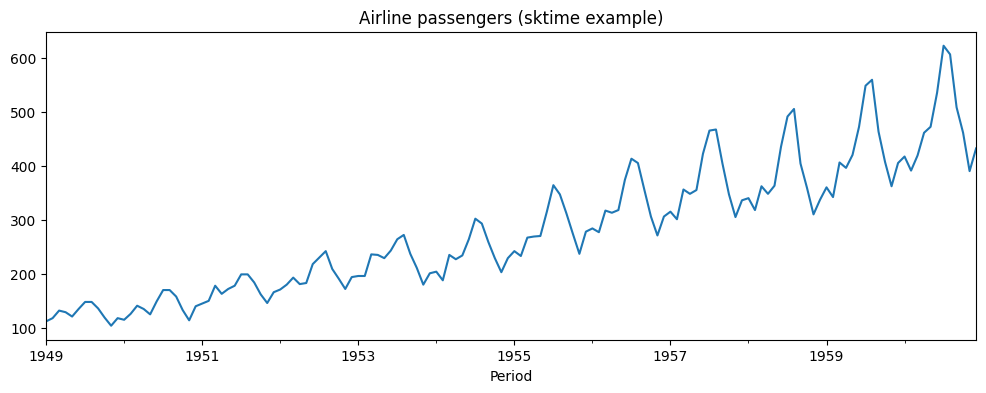

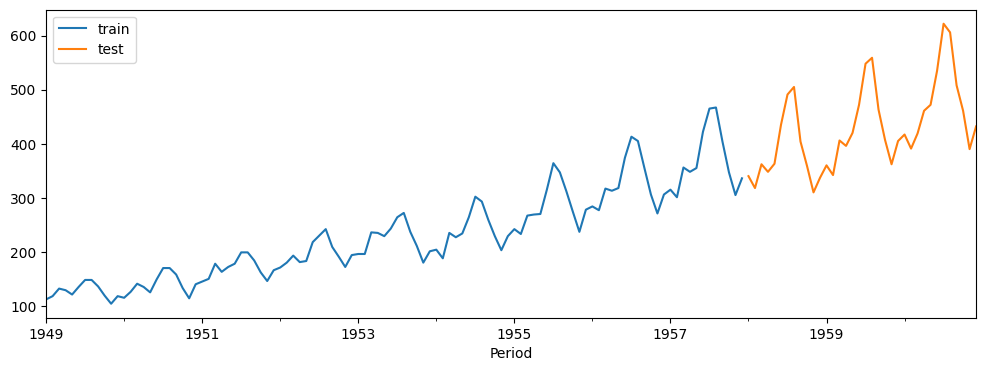

In [21]:
# Basic sktime imports
from sktime.datasets import load_airline
from sktime.forecasting.model_selection import temporal_train_test_split, ForecastingGridSearchCV
from sktime.forecasting.compose import TransformedTargetForecaster
from sktime.forecasting.exp_smoothing import ExponentialSmoothing
from sktime.forecasting.arima import ARIMA
from sktime.forecasting.base import ForecastingHorizon
from sktime.transformations.series.boxcox import BoxCoxTransformer
from sktime.performance_metrics.forecasting import mean_absolute_percentage_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor

# Load airline data (monthly)
y = load_airline()
y.plot(title='Airline passengers (sktime example)'); plt.show()

# Train/test split
y_train, y_test = temporal_train_test_split(y, test_size=36)
y_train.plot(label='train')
y_test.plot(label='test')
plt.legend(); plt.show()

In [22]:
# Example pipeline: BoxCox transform + ARIMA
pipe = TransformedTargetForecaster(steps=[
    ("boxcox", BoxCoxTransformer()),
    ("arima", ARIMA(order=(1,1,1)))
])

pipe.fit(y_train)
fh = ForecastingHorizon(y_test.index, is_relative=False)
y_pred = pipe.predict(fh)


print('MAPE:', mean_absolute_percentage_error(y_test, y_pred))
print('MAE:', mean_absolute_error(y_test, y_pred))

MAPE: 0.11686857995938582
MAE: 52.00889011928353


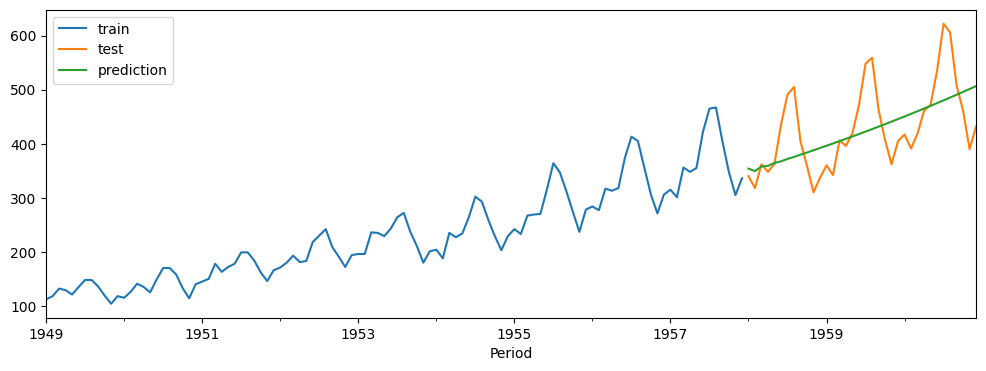

In [23]:
ax = y_train.rename('train').plot()
y_test.rename('test').plot(ax=ax)
y_pred.rename('prediction').plot(ax=ax)
ax.legend();

MAPE RF: 0.12915588933215946
MAE RF: 55.12222222222223


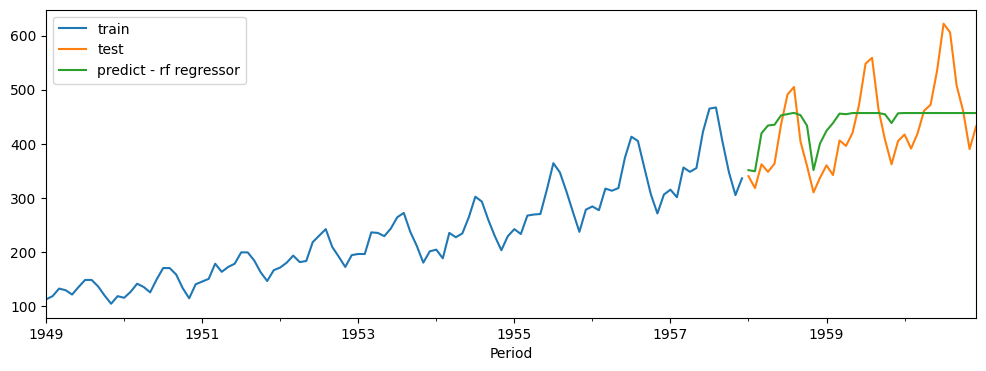

In [24]:
# Example: ReducedRegressionForecaster (ML approach) using lag features + RandomForest
from sktime.forecasting.compose import make_reduction
from sklearn.ensemble import RandomForestRegressor

regressor = RandomForestRegressor(n_estimators=100, random_state=42)
regr_forecaster = make_reduction(regressor, window_length=12, strategy="recursive")
regr_forecaster.fit(y_train)
y_pred_regr = regr_forecaster.predict(fh)

ax = y_train.rename('train').plot()
y_test.rename('test').plot(ax=ax)
y_pred_regr.rename('predict - rf regressor').plot(ax=ax)
ax.legend();

print('MAPE RF:', mean_absolute_percentage_error(y_test, y_pred_regr))
print('MAE RF:', mean_absolute_error(y_test, y_pred_regr))